# Classification of the Quality of Portuguese White Wines 

### Part 1: Import libraries, Load Data.

In [30]:
# import standard libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
%matplotlib inline
sns.set()

import sklearn.metrics as metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
# read data from '.csv' file
dataset = pd.read_csv('winequality.csv') 

### Part 2: Exploratory Data Analysis.

In [3]:
# print the full summary of the dataset  
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [4]:
# preview of the first 5 lines of the loaded data 
dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
dataset['quality'].describe()

count    4898.000000
mean        5.877909
std         0.885639
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         9.000000
Name: quality, dtype: float64

In [6]:
dataset[dataset['quality']==9]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
3991,9.1,0.27,0.45,10.6,0.035,28.0,124.0,0.99700,3.20,0.46,10.4,9
4002,6.6,0.36,0.29,1.6,0.021,24.0,85.0,0.98965,3.41,0.61,12.4,9
4003,7.4,0.24,0.36,2.0,0.031,27.0,139.0,0.99055,3.28,0.48,12.5,9
4030,6.9,0.36,0.34,4.2,0.018,57.0,119.0,0.98980,3.28,0.36,12.7,9
4204,7.1,0.26,0.49,2.2,0.032,31.0,113.0,0.99030,3.37,0.42,12.9,9


* ### Encoding 'quality' attribute

In [7]:
# lambda function; wine quality from 3-6 == 0, from 7-9 == 1.
dataset['quality'] = dataset.quality.apply(lambda q: 0 if q <= 6 else 1)

In [8]:
# preview of the first 5 lines of the loaded data 
dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,0
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,0


* ### 'quality' attribute value counts and visualisation

In [9]:
print('Not good wine', round(dataset['quality'].value_counts()[0]/len(dataset) * 100,2), '% of the dataset')
print('Good wine', round(dataset['quality'].value_counts()[1]/len(dataset) * 100,2), '% of the dataset')

dataset['quality'].value_counts()

Not good wine 78.36 % of the dataset
Good wine 21.64 % of the dataset


quality
0    3838
1    1060
Name: count, dtype: int64

<Axes: xlabel='quality'>

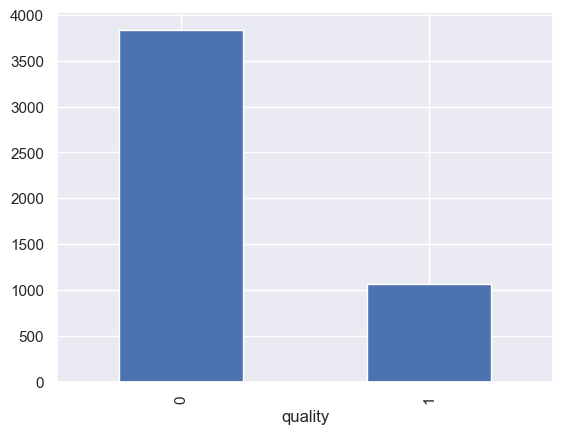

In [10]:
# visualisation plot
dataset['quality'].value_counts().plot(x = dataset['quality'], kind='bar')

* ### Resampling of an imbalanced dataset

In [11]:
# class count
count_class_0, count_class_1 = dataset.quality.value_counts()

# divide by class
class_0 = dataset[dataset['quality'] == 0]
class_1 = dataset[dataset['quality'] == 1]

* ### Random under-sampling of an imbalanced dataset

Random under-sampling:
quality
0    1060
1    1060
Name: count, dtype: int64


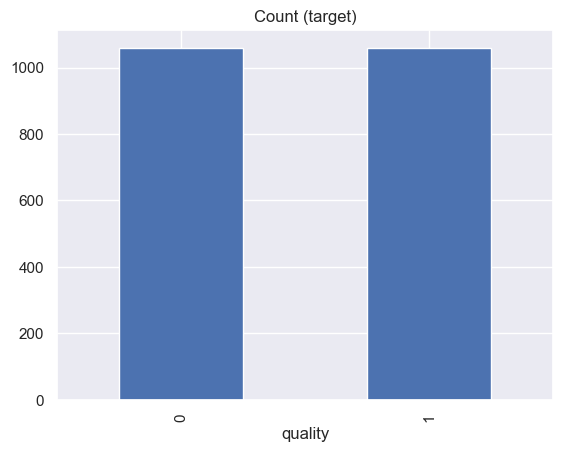

In [12]:
class_0_under = class_0.sample(count_class_1)
dataset_under = pd.concat([class_0_under, class_1], axis=0)

print('Random under-sampling:')
print(dataset_under.quality.value_counts())

dataset_under.quality.value_counts().plot(kind='bar', title='Count (target)');

* ### Random over-sampling of an imbalanced dataset

Random over-sampling:
quality
0    3838
1    3838
Name: count, dtype: int64


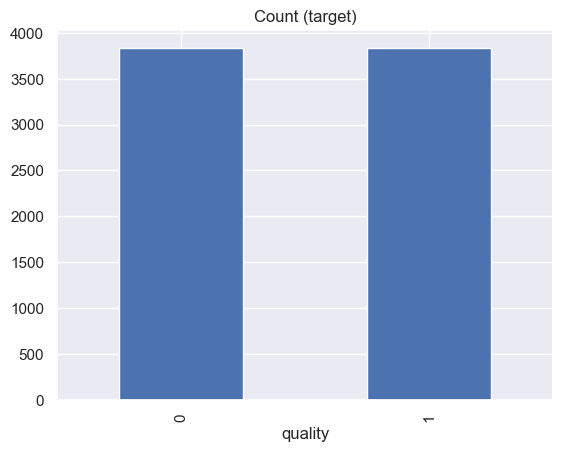

In [13]:
class_1_over = class_1.sample(count_class_0, replace=True)
dataset_over = pd.concat([class_0, class_1_over], axis=0)

print('Random over-sampling:')
print(dataset_over.quality.value_counts())

dataset_over.quality.value_counts().plot(kind='bar', title='Count (target)');

* ### Initialisation of target

In [14]:
# initialisation of target
target = dataset['quality']

# for under-sampling dataset
target_under = dataset_under['quality']

# for over-sampling dataset
target_over = dataset_over['quality'] 

* ### Drop column 'quality'

In [15]:
dataset = dataset.drop(columns=['quality'])

# for under-sampling dataset
dataset_under = dataset_under.drop(columns=['quality'])

# for over-sampling dataset
dataset_over = dataset_over.drop(columns=['quality'])

## Part 3: Data Wrangling and Transformation.

* ### Creating datasets for ML part

In [19]:
# set 'X' for features' and y' for the target ('quality').
y = target
X = dataset.copy()

# for under-sampling dataset 
y_under = target_under
X_under = dataset_under.copy()

# for over-sampling dataset 
y_over = target_over
X_over = dataset_over.copy()

In [20]:
# preview of the first 5 lines of the loaded data 
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9


* ### 'Train\Test' split

In [21]:
# apply 'Train\Test' splitting method
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55)
X_train_under, X_test_under, y_train_under, y_test_under = train_test_split(X_under, y_under, test_size=0.2, random_state=55)
X_train_over, X_test_over, y_train_over, y_test_over = train_test_split(X_over, y_over, test_size=0.2, random_state=55)

In [22]:
# print shape of X_train and y_train
X_train.shape, y_train.shape

((3918, 11), (3918,))

In [23]:
# print shape of X_test and y_test
X_test.shape, y_test.shape

((980, 11), (980,))

* ### StandardScaler

In [24]:
# StandardScaler 
sc = StandardScaler()

X_train = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(sc.transform(X_test), columns=X_test.columns, index=X_test.index)

# for under-sampling dataset
sc1 = StandardScaler()
X_train_under = pd.DataFrame(sc1.fit_transform(X_train_under), columns=X_train_under.columns, index=X_train_under.index)
X_test_under = pd.DataFrame(sc1.transform(X_test_under), columns=X_test_under.columns, index=X_test_under.index)

# for over-sampling dataset
sc2 = StandardScaler()
X_train_over = pd.DataFrame(sc2.fit_transform(X_train_over), columns=X_train_over.columns, index=X_train_over.index)
X_test_over = pd.DataFrame(sc2.transform(X_test_over), columns=X_test_over.columns, index=X_test_over.index)


<a id="Part-4-Machine-Learning"></a>
## Part 4: Machine Learning.

* ### Build, train and evaluate models without hyperparameters

* Logistic Regression
* K-Nearest Neighbors
* Decision Trees


In [27]:
# Logistic Regression
LR = LogisticRegression(random_state = 55)
LR.fit(X_train, y_train)
LR_pred = LR.predict(X_test)

# K-Nearest Neighbors
KNN = KNeighborsClassifier()
KNN.fit(X_train, y_train)
KNN_pred = KNN.predict(X_test)

# Decision Tree
DT = DecisionTreeClassifier(random_state = 55)
DT.fit(X_train, y_train)
DT_pred = DT.predict(X_test)

* ### Classification report

In [28]:
print("LR Classification Report: \n", classification_report(y_test, LR_pred, digits = 6))
print("KNN Classification Report: \n", classification_report(y_test, KNN_pred, digits = 6))
print("DT Classification Report: \n", classification_report(y_test, DT_pred, digits = 6))

LR Classification Report: 
               precision    recall  f1-score   support

           0   0.833522  0.947233  0.886747       777
           1   0.577320  0.275862  0.373333       203

    accuracy                       0.808163       980
   macro avg   0.705421  0.611548  0.630040       980
weighted avg   0.780452  0.808163  0.780397       980

KNN Classification Report: 
               precision    recall  f1-score   support

           0   0.877323  0.911197  0.893939       777
           1   0.601156  0.512315  0.553191       203

    accuracy                       0.828571       980
   macro avg   0.739240  0.711756  0.723565       980
weighted avg   0.820117  0.828571  0.823356       980

DT Classification Report: 
               precision    recall  f1-score   support

           0   0.901857  0.875161  0.888308       777
           1   0.570796  0.635468  0.601399       203

    accuracy                       0.825510       980
   macro avg   0.736327  0.755314  0.744853

In [31]:
# compare models

models = {
    'Logistic Regression': LR_pred,
    'K-Nearest Neighbors': KNN_pred, 
    'Decision Tree': DT_pred
}

results = []

for model_name, y_pred in models.items():
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results)
print(results_df.round(6))

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.808163   0.780452  0.808163  0.780397
1  K-Nearest Neighbors  0.828571   0.820117  0.828571  0.823356
2        Decision Tree  0.825510   0.833280  0.825510  0.828877


* ### Confusion matrix

In [32]:
LR_confusion_mx = confusion_matrix(y_test, LR_pred)
print("LR Confusion Matrix: \n", LR_confusion_mx)
print()
KNN_confusion_mx = confusion_matrix(y_test, KNN_pred)
print("KNN Confusion Matrix: \n", KNN_confusion_mx)
print()
DT_confusion_mx = confusion_matrix(y_test, DT_pred)
print("DT Confusion Matrix: \n", DT_confusion_mx)
print()

LR Confusion Matrix: 
 [[736  41]
 [147  56]]

KNN Confusion Matrix: 
 [[708  69]
 [ 99 104]]

DT Confusion Matrix: 
 [[680  97]
 [ 74 129]]



* ### ROC-AUC score

In [33]:
roc_auc_score(LR_pred, y_test)

0.7054208357170377

In [34]:
roc_auc_score(KNN_pred, y_test)

0.7392397447192556

In [35]:
roc_auc_score(DT_pred, y_test)

0.7363266120513604

In [ ]:
#model with balanced datasets with over/under-sampling and class_weight='balanced'

LR_over = LogisticRegression(max_iter=1000, random_state = 55)
LR_over.fit(X_train_over, y_train_over)
LR_over_pred = LR_over.predict(X_test_over)

LR_under = LogisticRegression(max_iter=1000, random_state = 55)
LR_under.fit(X_train_under, y_train_under)
LR_under_pred = LR_under.predict(X_test_under)

LR_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state = 55)
LR_weighted.fit(X_train, y_train)
LR_weighted_pred = LR_weighted.predict(X_test)

In [ ]:
# compare models
# use the correct test set for each model (original, over-sampled, under-sampled)

models = {
    'Logistic Regression': (LR_pred, y_test),
    'K-Nearest Neighbors': (KNN_pred, y_test), 
    'Decision Tree': (DT_pred, y_test),
    'Logistic Regression Over-sampling': (LR_over_pred, y_test_over),
    'Logistic Regression Under-sampling': (LR_under_pred, y_test_under),
    'Logistic Regression Weighted': (LR_weighted_pred, y_test)
}

results = []

for model_name, (y_pred, y_true) in models.items():
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1-Score': f1_score(y_true, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results)
print(results_df.round(6))

                                Model  Accuracy  Precision    Recall  F1-Score
0                 Logistic Regression  0.808163   0.780452  0.808163  0.780397
1                 K-Nearest Neighbors  0.828571   0.820117  0.828571  0.823356
2                       Decision Tree  0.825510   0.833280  0.825510  0.828877
3   Logistic Regression Over-sampling  0.729167   0.731231  0.729167  0.729084
4  Logistic Regression Under-sampling  0.731132   0.731468  0.731132  0.730892
5        Logistic Regression Weighted  0.716327   0.799213  0.716327  0.740142


* ### Build, train and evaluate models with hyperparameters

In [42]:
# Logistic Regression
LR1 = LogisticRegression(max_iter=1000, random_state = 55)
LR1_params = [
    {
        'penalty': ['l1'],
        'C': [1, 2, 3, 4, 5],
        'solver': ['liblinear', 'saga']
    },
    {
        'penalty': ['l2'], 
        'C': [1, 2, 3, 4, 5],
        'solver': ['lbfgs', 'newton-cg', 'liblinear', 'sag', 'saga']
    },
    {
        'penalty': ['elasticnet'],
        'C': [1, 2, 3, 4, 5],
        'solver': ['saga'],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    {
        'penalty': ['none'],
        'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']
    }
]
LR1 = GridSearchCV(LR1, param_grid = LR1_params, cv=5, scoring='f1', n_jobs=-1, verbose=1, refit=True)
LR1.fit(X_train, y_train)
LR1_pred = LR1.predict(X_test)

# K-Nearest Neighbors
KNN1 = KNeighborsClassifier()
KNN1_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
KNN1 = GridSearchCV(KNN1, param_grid = KNN1_params, scoring='accuracy', cv=5, n_jobs=-1)             
KNN1.fit(X_train, y_train)
KNN1_pred = KNN1.predict(X_test)

# Decision Tree
DT1 = DecisionTreeClassifier(random_state=55)
DT1_params = {
    'max_depth': [2, 5, 10, 15, 20],
    'min_samples_split': [4, 7, 10],
    'min_samples_leaf': [1, 2, 4, 7],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}
DT1 = GridSearchCV(DT1, param_grid = DT1_params, scoring='accuracy', cv=5, n_jobs=-1)
DT1.fit(X_train, y_train)
DT1_pred = DT1.predict(X_test)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


In [43]:
# print the best hyper parameters set
print("Logistic Regression Best Hyper Parameters:   ", LR1.best_params_)
print("K-Nearest Neighbour Best Hyper Parameters:   ", KNN1.best_params_)
print("Decision Tree Best Hyper Parameters:         ", DT1.best_params_)

Logistic Regression Best Hyper Parameters:    {'C': 5, 'l1_ratio': 0.7, 'penalty': 'elasticnet', 'solver': 'saga'}
K-Nearest Neighbour Best Hyper Parameters:    {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
Decision Tree Best Hyper Parameters:          {'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 4}


* ### Classification report

In [44]:
print("LR Classification Report: \n", classification_report(y_test, LR1_pred, digits = 6))
print("KNN Classification Report: \n", classification_report(y_test, KNN1_pred, digits = 6))
print("DT Classification Report: \n", classification_report(y_test, DT1_pred, digits = 6))

LR Classification Report: 
               precision    recall  f1-score   support

           0   0.833522  0.947233  0.886747       777
           1   0.577320  0.275862  0.373333       203

    accuracy                       0.808163       980
   macro avg   0.705421  0.611548  0.630040       980
weighted avg   0.780452  0.808163  0.780397       980

KNN Classification Report: 
               precision    recall  f1-score   support

           0   0.902829  0.944659  0.923270       777
           1   0.742515  0.610837  0.670270       203

    accuracy                       0.875510       980
   macro avg   0.822672  0.777748  0.796770       980
weighted avg   0.869621  0.875510  0.870863       980

DT Classification Report: 
               precision    recall  f1-score   support

           0   0.867879  0.921493  0.893883       777
           1   0.606452  0.463054  0.525140       203

    accuracy                       0.826531       980
   macro avg   0.737165  0.692274  0.709511

* ### Confusion matrix

In [45]:
KNN_confusion_mx = confusion_matrix(y_test, KNN_pred)
print("KNN Confusion Matrix: \n", KNN_confusion_mx)
print()
LR_confusion_mx = confusion_matrix(y_test, LR_pred)
print("LR Confusion Matrix: \n", LR_confusion_mx)   
print()
DT_confusion_mx = confusion_matrix(y_test, DT_pred)
print("DT Confusion Matrix: \n", DT_confusion_mx)

KNN Confusion Matrix: 
 [[708  69]
 [ 99 104]]

LR Confusion Matrix: 
 [[736  41]
 [147  56]]

DT Confusion Matrix: 
 [[680  97]
 [ 74 129]]


In [46]:
# compare models
# use the correct test set for each model (original, over-sampled, under-sampled)

models = {
    'Logistic Regression': (LR_pred, y_test),
    'K-Nearest Neighbors': (KNN_pred, y_test), 
    'Decision Tree': (DT_pred, y_test),
    'Logistic Regression Over-sampling': (LR_over_pred, y_test_over),
    'Logistic Regression Under-sampling': (LR_under_pred, y_test_under),
    'Logistic Regression Weighted': (LR_weighted_pred, y_test),
    'Tuned Logistic Regression': (LR1_pred, y_test),
    'Tuned K-Nearest Neighbors': (KNN1_pred, y_test),
    'Tuned Decision Tree': (DT1_pred, y_test)
}

results = []

for model_name, (y_pred, y_true) in models.items():
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1-Score': f1_score(y_true, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results)
print(results_df.round(6))

                                Model  Accuracy  Precision    Recall  F1-Score
0                 Logistic Regression  0.808163   0.780452  0.808163  0.780397
1                 K-Nearest Neighbors  0.828571   0.820117  0.828571  0.823356
2                       Decision Tree  0.825510   0.833280  0.825510  0.828877
3   Logistic Regression Over-sampling  0.729167   0.731231  0.729167  0.729084
4  Logistic Regression Under-sampling  0.731132   0.731468  0.731132  0.730892
5        Logistic Regression Weighted  0.716327   0.799213  0.716327  0.740142
6           Tuned Logistic Regression  0.808163   0.780452  0.808163  0.780397
7           Tuned K-Nearest Neighbors  0.875510   0.869621  0.875510  0.870863
8                 Tuned Decision Tree  0.826531   0.813726  0.826531  0.817500


DT Confusion Matrix


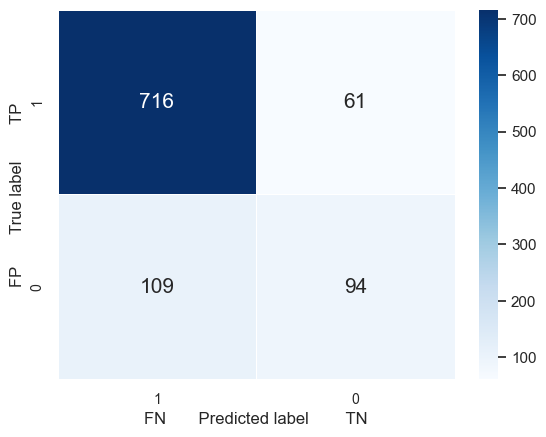

In [48]:
# confusion matrix of DT model
DT_confusion_mx = confusion_matrix(y_test, DT1_pred)
print('DT Confusion Matrix')

# visualisation
ax = plt.subplot()
sns.heatmap(DT_confusion_mx, annot = True, fmt = 'd', cmap = 'Blues', ax = ax, linewidths = 0.5, annot_kws = {'size': 15})
ax.set_ylabel('FP       True label        TP')
ax.set_xlabel('FN       Predicted label        TN')
ax.xaxis.set_ticklabels(['1', '0'], fontsize = 10)
ax.yaxis.set_ticklabels(['1', '0'], fontsize = 10)
plt.show()
print() 

* ### ROC-AUC score

In [49]:
print(roc_auc_score(LR1_pred, y_test))
print(roc_auc_score(KNN1_pred, y_test))
print(roc_auc_score(DT1_pred, y_test))

0.7054208357170377
0.8226719991750816
0.737165200391007


##  Conclusion.

In [34]:
# submission of .csv file with predictions
sub = pd.DataFrame()
sub['ID'] = X_test.index
sub['quality'] = DT1_pred
sub.to_csv('WinePredictionsTest.csv', index=False)

Основная проблема - все модели плохо справляются с классом 1, что видно по низкому recall (25-53%).

Анализ эффективности оптимизации (низкая)  
Настройка гиперпараметров через GridCV не привела к значительному улучшению качества моделей. Логистическая регрессия получила минимальное улучшение, KNN сохранил прежние показатели, а дерево решений показало снижение производительности. 

Почему оптимизация не сработала  
GridSearchCV подобрал параметры, но они не улучшили модели. Возможные причины:

Данные уже хорошо разделяются базовыми настройками  
Параметры были подобраны не оптимально  
Не хватает данных для существенного улучшения

Рекомендации по улучшению
Для повышения качества классификации можно рассмотреть ансамблевые методы, такие как случайный лес или градиентный бустинг, которые часто показывают лучшие результаты на несбалансированных данных. Дополнительная работа с признаками, включая отбор и создание новых переменных, может улучшить идентификацию класса 1. Для логистической регрессии стоит экспериментировать с техниками балансировки классов через class_weight или методы семплирования.

In [50]:
# переберм больше пораметров на оптимизации модели DT

DT2 = DecisionTreeClassifier(random_state=55)
DT2_params = {'max_depth':[4,6,8,10,12,15], 'criterion':['gini', 'entropy', 'log_loss',], 'min_samples_split':[2,4,7,10], 'min_samples_leaf':[1,2,4]}
DT2_gs = GridSearchCV(DT2, param_grid = DT2_params, cv=5, n_jobs=-1)
DT2_gs.fit(X_train, y_train)
DT2_gs_pred = DT2_gs.predict(X_test)

print("DT2 Classification Report: \n", classification_report(y_test, DT2_gs_pred, digits = 6))
print("DT2 Best Hyper Parameters:         ", DT2_gs.best_params_)  
print(roc_auc_score(DT2_gs_pred, y_test))

DT2 Classification Report: 
               precision    recall  f1-score   support

           0   0.882500  0.908623  0.895371       777
           1   0.605556  0.536946  0.569191       203

    accuracy                       0.831633       980
   macro avg   0.744028  0.722784  0.732281       980
weighted avg   0.825133  0.831633  0.827805       980

DT2 Best Hyper Parameters:          {'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 4, 'min_samples_split': 2}
0.7440277777777778


In [51]:
DT2_gs.confusion_mx = confusion_matrix(y_test, DT2_gs_pred)
print("DT2 Confusion Matrix: \n", DT2_gs.confusion_mx)

DT2 Confusion Matrix: 
 [[706  71]
 [ 94 109]]


In [ ]:
# что если использовать Random Forest или Gradient Boosting

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [53]:
# тренируем модель Random Forest
RF = RandomForestClassifier(class_weight='balanced', random_state=55)
RF_params = {'n_estimators':[100,150,200,250], 'max_depth':[8,10,12,15], 'criterion':['gini', 'entropy'], 'min_samples_split':[2,3,4,5], 'min_samples_leaf':[1,2,3,4]}
RF_gs = GridSearchCV(RF, param_grid = RF_params, cv=5, n_jobs=-1)
RF_gs.fit(X_train, y_train)
RF_gs_pred = RF_gs.predict(X_test)

print("RF Classification Report: \n", classification_report(y_test, RF_gs_pred, digits = 6))
print("RF Best Hyper Parameters:         ", RF_gs.best_params_)
print(roc_auc_score(RF_gs_pred, y_test))

# confusion matrix of RF model
RF_gs.confusion_mx = confusion_matrix(y_test, RF_gs_pred)
print("RF Confusion Matrix: \n", RF_gs.confusion_mx)

RF Classification Report: 
               precision    recall  f1-score   support

           0   0.911361  0.939511  0.925222       777
           1   0.737430  0.650246  0.691099       203

    accuracy                       0.879592       980
   macro avg   0.824395  0.794879  0.808161       980
weighted avg   0.875332  0.879592  0.876725       980

RF Best Hyper Parameters:          {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
0.8243954832995068
RF Confusion Matrix: 
 [[730  47]
 [ 71 132]]


In [54]:
# если сравнить с gradient boosting?
GB = GradientBoostingClassifier(random_state=55)
GB_params = {'n_estimators':[100,150,200], 'learning_rate':[0.01,0.05,0.1], 'max_depth':[3,5,7], 'min_samples_split':[2,3,4], 'min_samples_leaf':[1,2,3]}
GB_gs = GridSearchCV(GB, param_grid = GB_params, cv=5, n_jobs=-1)
GB_gs.fit(X_train, y_train)
GB_gs_pred = GB_gs.predict(X_test)

print("GB Classification Report: \n", classification_report(y_test, GB_gs_pred, digits = 6))
print("GB Best Hyper Parameters:         ", GB_gs.best_params_)
print(roc_auc_score(GB_gs_pred, y_test))
# confusion matrix of GB model
GB_gs.confusion_mx = confusion_matrix(y_test, GB_gs_pred)
print("GB Confusion Matrix: \n", GB_gs.confusion_mx)

GB Classification Report: 
               precision    recall  f1-score   support

           0   0.906098  0.956242  0.930495       777
           1   0.787500  0.620690  0.694215       203

    accuracy                       0.886735       980
   macro avg   0.846799  0.788466  0.812355       980
weighted avg   0.881531  0.886735  0.881551       980

GB Best Hyper Parameters:          {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
0.846798780487805
GB Confusion Matrix: 
 [[743  34]
 [ 77 126]]


In [55]:
from sklearn.ensemble import VotingClassifier


# Создание ансамбля
ensemble = VotingClassifier(
    estimators=[
        ('rf', RF_gs.best_estimator_),  # наш лучший Random Forest
        ('gb', GB_gs.best_estimator_),  # Gradient Boosting
        ('dt2', DT2_gs.best_estimator_)  # добавим DT
    ],
    voting='soft',  # использовать вероятности
    weights=[3, 2, 1]  # веса на основе качества моделей
)
ensemble.fit(X_train, y_train)
ensemble_pred = ensemble.predict(X_test)
print("Ensemble Classification Report: \n", classification_report(y_test, ensemble_pred, digits = 6))
print("Ensemble ROC AUC Score: ", roc_auc_score(y_test, ensemble_pred))



Ensemble Classification Report: 
               precision    recall  f1-score   support

           0   0.910649  0.957529  0.933501       777
           1   0.797546  0.640394  0.710383       203

    accuracy                       0.891837       980
   macro avg   0.854097  0.798962  0.821942       980
weighted avg   0.887220  0.891837  0.887283       980

Ensemble ROC AUC Score:  0.7989615230994541


In [ ]:
from sklearn.svm import SVC

diverse_ensemble = VotingClassifier(
    estimators=[
        ('rf', RF_gs.best_estimator_),
        ('gb', GB_gs.best_estimator_), 
        ('svm', SVC(probability=True))
    ],
    voting='soft'
)
diverse_ensemble.fit(X_train, y_train)
diverse_ensemble_pred = diverse_ensemble.predict(X_test)
print("Diverse Ensemble Classification Report: \n", classification_report(y_test, diverse_ensemble_pred, digits = 6))
print("Diverse Ensemble ROC AUC Score: ", roc_auc_score(y_test, diverse_ensemble_pred))

Diverse Ensemble Classification Report: 
               precision    recall  f1-score   support

           0   0.905225  0.958816  0.931250       777
           1   0.796178  0.615764  0.694444       203

    accuracy                       0.887755       980
   macro avg   0.850702  0.787290  0.812847       980
weighted avg   0.882637  0.887755  0.882197       980

Diverse Ensemble ROC AUC Score:  0.7872897528069942


In [58]:
# compare models
# use the correct test set for each model (original, over-sampled, under-sampled)

models = {
    'Logistic Regression': (LR_pred, y_test),
    'K-Nearest Neighbors': (KNN_pred, y_test), 
    'Decision Tree': (DT_pred, y_test),
    'LR Over-sampling': (LR_over_pred, y_test_over),
    'LR Under-sampling': (LR_under_pred, y_test_under),
    'LR Weighted': (LR_weighted_pred, y_test),
    'Tuned Logistic Regression': (LR1_pred, y_test),
    'Tuned K-Nearest Neighbors': (KNN1_pred, y_test),
    'Tuned Decision Tree': (DT1_pred, y_test),
    'Tuned Desicion Tree 2': (DT2_gs_pred, y_test),
    'Tuned Random Forest': (RF_gs_pred, y_test),
    'Tuned Gradient Boosting': (GB_gs_pred, y_test),
    'Ensemble': (ensemble_pred, y_test),
    'Diverse Ensemble': (diverse_ensemble_pred, y_test)
}

results = []

for model_name, (y_pred, y_true) in models.items():
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1-Score': f1_score(y_true, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results)
print(results_df.round(6))

                        Model  Accuracy  Precision    Recall  F1-Score
0         Logistic Regression  0.808163   0.780452  0.808163  0.780397
1         K-Nearest Neighbors  0.828571   0.820117  0.828571  0.823356
2               Decision Tree  0.825510   0.833280  0.825510  0.828877
3            LR Over-sampling  0.729167   0.731231  0.729167  0.729084
4           LR Under-sampling  0.731132   0.731468  0.731132  0.730892
5                 LR Weighted  0.716327   0.799213  0.716327  0.740142
6   Tuned Logistic Regression  0.808163   0.780452  0.808163  0.780397
7   Tuned K-Nearest Neighbors  0.875510   0.869621  0.875510  0.870863
8         Tuned Decision Tree  0.826531   0.813726  0.826531  0.817500
9       Tuned Desicion Tree 2  0.831633   0.825133  0.831633  0.827805
10        Tuned Random Forest  0.879592   0.875332  0.879592  0.876725
11    Tuned Gradient Boosting  0.886735   0.881531  0.886735  0.881551
12                   Ensemble  0.891837   0.887220  0.891837  0.887283
13    

In [63]:
# final summary table
results_summary = [
    {'Model': 'LR (baseline)', 'Accuracy': 0.808163, 'F1-Score': 0.780397, 'ROC-AUC': 0.705421, 'Precision_1': 0.577320, 'Recall_1': 0.275862},
    {'Model': 'KNN (baseline)', 'Accuracy': 0.828571, 'F1-Score': 0.823356, 'ROC-AUC': 0.739240, 'Precision_1': 0.601156, 'Recall_1': 0.512315},
    {'Model': 'Decision Tree (baseline)', 'Accuracy': 0.825510, 'F1-Score': 0.828877, 'ROC-AUC': 0.736327, 'Precision_1': 0.570796, 'Recall_1': 0.635468},
    
    {'Model': 'LR (tuned)', 'Accuracy': 0.808163, 'F1-Score': 0.780397, 'ROC-AUC': 0.705421, 'Precision_1': 0.577320, 'Recall_1': 0.275862},
    {'Model': 'KNN (tuned)', 'Accuracy': 0.875510, 'F1-Score': 0.870863, 'ROC-AUC': 0.822672, 'Precision_1': 0.742515, 'Recall_1': 0.610837},
    {'Model': 'Decision Tree (tuned v1)', 'Accuracy': 0.826531, 'F1-Score': 0.817500, 'ROC-AUC': 0.737165, 'Precision_1': 0.606452, 'Recall_1': 0.463054},
    {'Model': 'Decision Tree (tuned v2)', 'Accuracy': 0.831633, 'F1-Score': 0.827805, 'ROC-AUC': 0.744028, 'Precision_1': 0.605556, 'Recall_1': 0.536946},
    
    {'Model': 'Random Forest', 'Accuracy': 0.879592, 'F1-Score': 0.876725, 'ROC-AUC': 0.824395, 'Precision_1': 0.737430, 'Recall_1': 0.650246},
    {'Model': 'Gradient Boosting', 'Accuracy': 0.886735, 'F1-Score': 0.881551, 'ROC-AUC': 0.846799, 'Precision_1': 0.787500, 'Recall_1': 0.620690},
    
    {'Model': 'Ensemble (RF+GB+DT)', 'Accuracy': 0.891837, 'F1-Score': 0.887283, 'ROC-AUC': 0.798962, 'Precision_1': 0.797546, 'Recall_1': 0.640394},
    {'Model': 'Diverse Ensemble', 'Accuracy': 0.887755, 'F1-Score': 0.882197, 'ROC-AUC': 0.787290, 'Precision_1': 0.796178, 'Recall_1': 0.615764}
]

pd.set_option('display.max_columns', None)  # Показывать все колонки
pd.set_option('display.expand_frame_repr', False)  # Не переносить на новую строку

results_df = pd.DataFrame(results_summary)
print(results_df.round(6))

                       Model  Accuracy  F1-Score   ROC-AUC  Precision_1  Recall_1
0              LR (baseline)  0.808163  0.780397  0.705421     0.577320  0.275862
1             KNN (baseline)  0.828571  0.823356  0.739240     0.601156  0.512315
2   Decision Tree (baseline)  0.825510  0.828877  0.736327     0.570796  0.635468
3                 LR (tuned)  0.808163  0.780397  0.705421     0.577320  0.275862
4                KNN (tuned)  0.875510  0.870863  0.822672     0.742515  0.610837
5   Decision Tree (tuned v1)  0.826531  0.817500  0.737165     0.606452  0.463054
6   Decision Tree (tuned v2)  0.831633  0.827805  0.744028     0.605556  0.536946
7              Random Forest  0.879592  0.876725  0.824395     0.737430  0.650246
8          Gradient Boosting  0.886735  0.881551  0.846799     0.787500  0.620690
9        Ensemble (RF+GB+DT)  0.891837  0.887283  0.798962     0.797546  0.640394
10          Diverse Ensemble  0.887755  0.882197  0.787290     0.796178  0.615764


# Вывод:  
